# Online Convex Optimization

Imports

In [1]:
import numpy as np
import pandas as pd
import random as rd
import matplotlib.pyplot as plt

LinearSVM

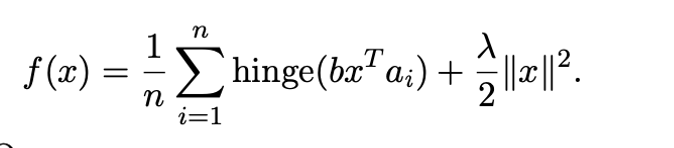
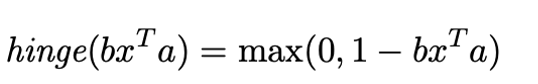

In [12]:
class LinearSVM:
    def __init__(self, m):
        self.w = np.random.randn(m)
    
    def loss(self, a, b, l):
        hinge = 1 - (a.dot(self.w)*b)
        hinge[np.where(hinge <= 0)] = 0
        return np.mean(hinge) + l/2*np.linalg.norm(self.w, 2)**2
    
    def gradLoss(self, a, b, l):

        if b.shape != ():
            grad = (-np.repeat(b[:, np.newaxis], a.shape[1], 1)) * a
        else:
            grad = - b * a
        temp = 1 - (a.dot(self.w)*b)
        grad[np.where(temp <= 0)] = 0
        return np.mean(grad) + l*self.w
    
    def predict(self, data):
        return np.sign(data.dot(self.w))
    

Gradient Descent

In [14]:
def gd(model, X, y, epoch, l, verbose = 0, lr = 1):
    losses = []
    wts = [model.w]

    for i in range(epoch):
        t = i + 1
        dlr = lr/(l*t)
        new_wts = wts[-1] - dlr* model.gradLoss(X, y, l)
        wts.append(new_wts)
        model.w = new_wts
        current_loss = model.loss(X, y, l)
        losses += [current_loss]

        if verbose > 0 and i % verbose== 0:
            print(f"Epoch {i}, Loss {current_loss}")

    return losses, np.array(wts)

Stochastic Gradient Descent

In [16]:
def sgd(model, X, y, epoch, l, verbose = 0, lr = 1):
    losses = []
    wts = [model.w]

    n, _ = X.shape

    for i in range(epoch):

        idx = rd.randint(0, n-1)
        sample_x = X[idx, :].reshape(1, -1)
        sample_y = np.array(y[idx])

        t = i + 1
        dlr = lr/(l*t)
        new_wts = (1 - 1/t) * wts[-1] - dlr* model.gradLoss(sample_x, sample_y, l)

        wts.append(new_wts)
        model.w = new_wts
        current_loss = model.loss(X, y, l)
        losses += [current_loss]

        if verbose > 0 and i % verbose== 0:
            print(f"Epoch {i}, Loss {current_loss}")
    model.w = np.mean(wts, axis = 0)
    return losses, np.array(wts)

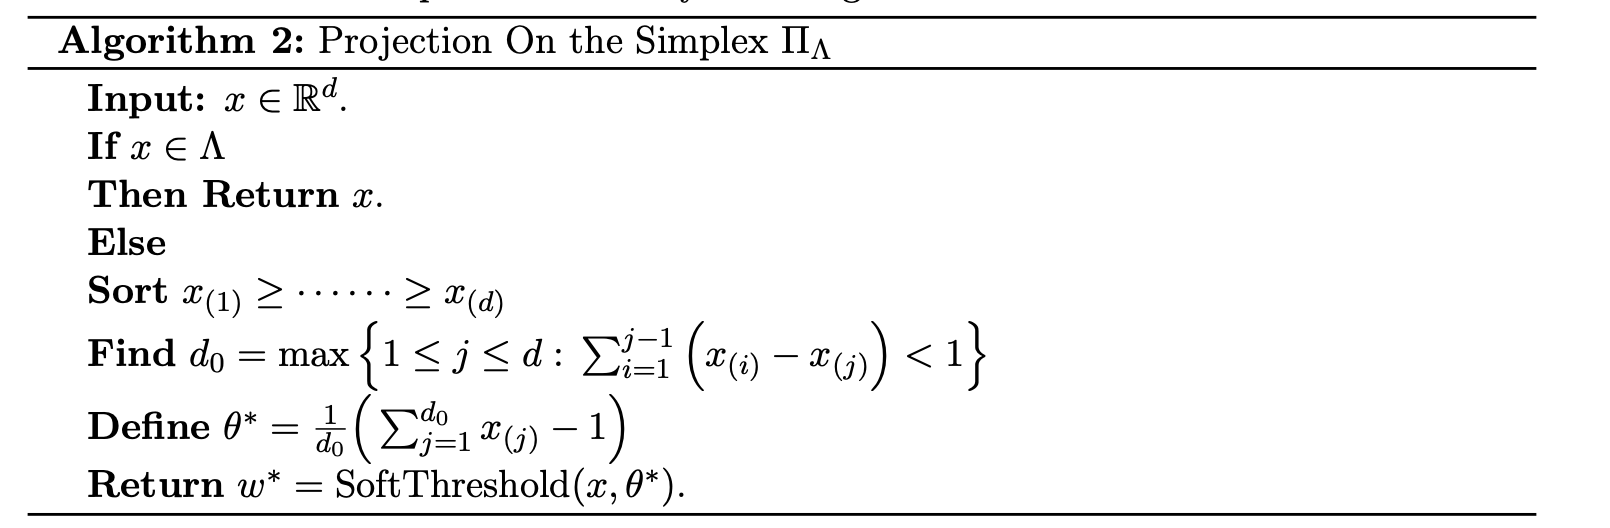

In [19]:
def proj_simplex(x):
    if np.sum(np.abs(x)) <= 1:
        return x
    
    x_s = np.sort(x, kind = 'quicksort')[::-1]
    cum_s = np.cumsum(x_s)
    res = x_s - (cum_s - 1)/ (np.arange(len(x))+1)
    d0 = np.max(np.where(res>0)) + 1
    theta = (cum_s[d0-1]-1)/d0
    return np.maximum(0, x - theta)


def proj_l1(x, z = 1):
    if np.sum(np.abs(x)) <= z:
        return x
    else:
        w = proj_simplex(abs(x)/z)
        return z * np.sign(x) * w


Stochastic Mirror Descent

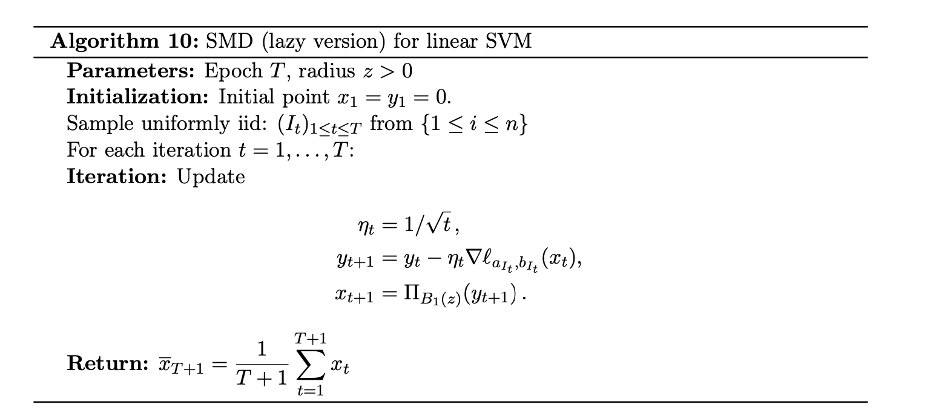

In [32]:
def smd(model, X, y, epoch, l, verbose = 0, lr = 1, z = 1):
    losses = []
    wts = [model.w]

    n, _ = X.shape

    for i in range(epoch):

        idx = rd.randint(0, n-1)
        sample_x = X[idx, :].reshape(1, -1)
        sample_y = np.array(y[idx])

        t = i + 1
        dlr = lr/(np.sqrt(t))
        new_wts = wts[-1] - dlr* model.gradLoss(sample_x, sample_y, l)

        
        new_wts = proj_l1(new_wts, z)
        wts.append(new_wts)
        model.w = new_wts
        current_loss = model.loss(X, y, l)
        losses += [current_loss]

        if verbose > 0 and i % verbose== 0:
            print(f"Epoch {i}, Loss {current_loss}")
            
    model.w = np.mean(wts, axis = 0)
    return losses, np.array(wts)



Initialization

In [39]:
np.random.seed(123)

lr = 0.1
nepoch = 2000
lbd = 1/3
z = 100
gamma = 1/8
verbose = 100

In [22]:
mnist_train = pd.read_csv('mnist_train.csv', sep=',', header=None)   # Reading
# Extract data
train_data = mnist_train.values[:, 1:]
# Normalize data
train_data = train_data / np.max(train_data)
train_data

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [23]:
train_data.shape

(60000, 784)

In [24]:
train_data = np.c_[train_data, np.ones(train_data.shape[0])] 
train_data

array([[0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 1.],
       ...,
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 1.]])

In [25]:
# Extract labels
train_labels = mnist_train.values[:, 0]
# if labels is not 0 => -1 (Convention chosen)
train_labels[np.where(train_labels != 0)] = -1
# if label is 0 ==> 1
train_labels[np.where(train_labels == 0)] = 1

mnist_test = pd.read_csv('mnist_test.csv', sep=',', header=None)
test_data = mnist_test.values[:, 1:]
test_data = test_data / np.max(test_data)
test_data = np.c_[test_data, np.ones(test_data.shape[0])]
test_labels = mnist_test.values[:, 0]
test_labels[np.where(test_labels != 0)] = -1
test_labels[np.where(test_labels == 0)] = 1

time_dict = {}

n, m = train_data.shape
print('Ready!')

Ready!


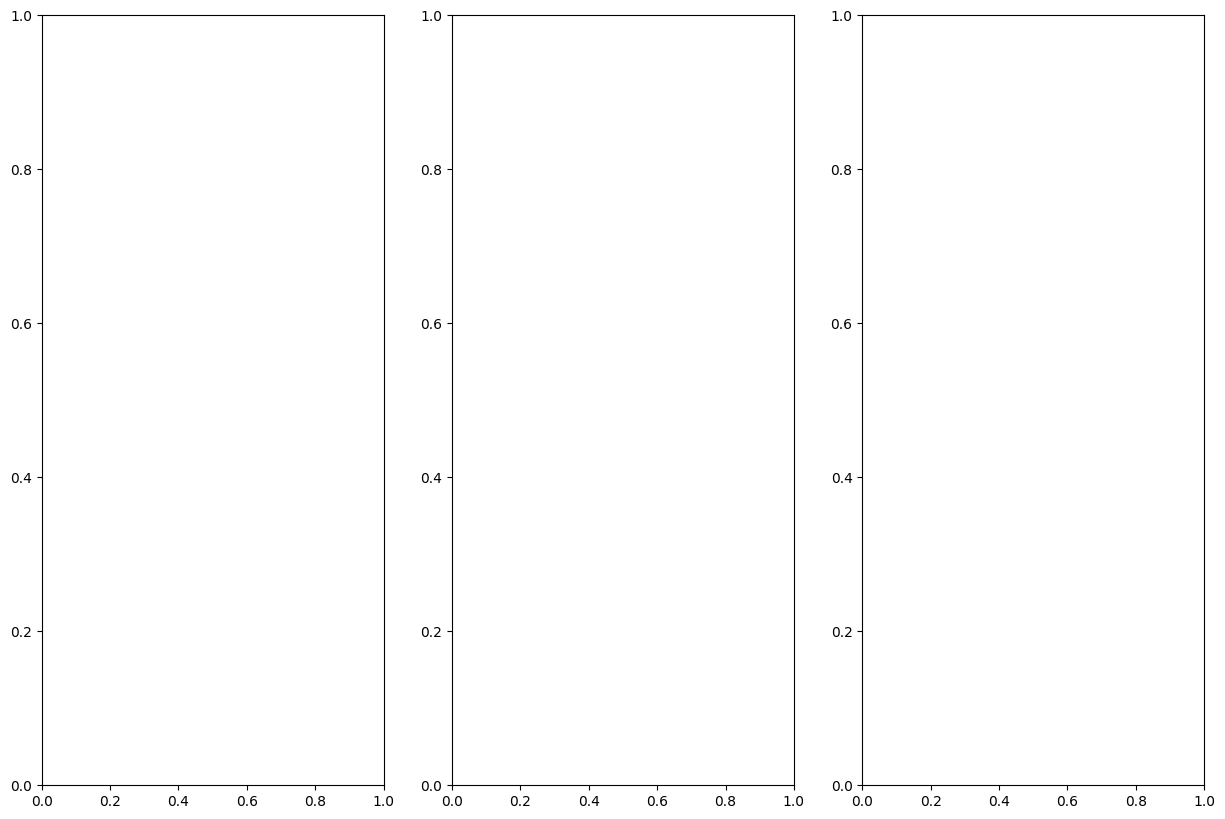

In [40]:
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(15, 10))

### Gradient Descent 

In [27]:
import time

In [28]:
from utils import *

In [29]:
print("-----------GD----------- \n")
model = LinearSVM(m)
tic = time.time()

GDloss, wts = gd(model, train_data, train_labels, nepoch, lbd, verbose, lr)

time_dict['gd'] = (time.time() - tic)

pred_test_labels = model.predict(test_data)

GDacc = accuracy(test_labels, pred_test_labels)

print('After {:3d} epoch, Unconstrained GD algorithm has a loss of {:1.6f} and accuracy {:1.6f}'.format(nepoch, GDloss[-1], GDacc))

ax[0].plot(np.arange(nepoch), GDloss, label = 'gd')
GDaccuracies = compute_accuracies(wts, test_data, test_labels)
ax[1].plot(GDaccuracies, label = 'gd')
GDerrors = compute_errors(wts, test_data, test_labels)
ax[2].plot(GDerrors, label = 'gd')

-----------GD----------- 

Epoch 0, Loss 109.99520008126144
Epoch 100, Loss 47.5919722915635
Epoch 200, Loss 41.568118686758616
Epoch 300, Loss 38.39407661391542
Epoch 400, Loss 36.288091359596486
Epoch 500, Loss 34.73387579539772
Epoch 600, Loss 33.51338370166085
Epoch 700, Loss 32.514983574082514
Epoch 800, Loss 31.674247733126833
Epoch 900, Loss 30.95078969250472
After 1000 epoch, Unconstrained GD algorithm has a loss of 30.323663 and accuracy 0.812900


### Stochastic Gradient Descent 

In [41]:
print("-----------SGD----------- \n")
model = LinearSVM(m)
tic = time.time()

SGDloss, wts = sgd(model, train_data, train_labels, nepoch, lbd, verbose, 1)
time_dict['sgd'] = (time.time() - tic)
pred_test_labels = model.predict(test_data)
acc = accuracy(test_labels, pred_test_labels)
print('After {:3d} epoch, Unconstrained SGD algorithm has a loss of {:1.6f} and accuracy {:1.6f}'.format(nepoch, SGDloss[-1], acc))

ax[0].plot(np.arange(nepoch), SGDloss, label = 'sgd')
SGDaccuracies = compute_accuracies(wts, test_data, test_labels)
ax[1].plot(SGDaccuracies, label = 'sgd')
SGDerrors = compute_errors(wts, test_data, test_labels)
ax[2].plot(SGDerrors, label = 'sgd')

-----------SGD----------- 

Epoch 0, Loss 140.342176916987
Epoch 100, Loss 0.34187917816593505
Epoch 200, Loss 0.34317210033482975
Epoch 300, Loss 0.34223819237175773
Epoch 400, Loss 0.34541952962890105
Epoch 500, Loss 0.3430260072122803
Epoch 600, Loss 0.34187258527311154
Epoch 700, Loss 0.341823401863459
Epoch 800, Loss 0.3429742376509882
Epoch 900, Loss 0.34199830465344977
Epoch 1000, Loss 0.3646037853084075
Epoch 1100, Loss 0.34186938722496785
Epoch 1200, Loss 0.34676404045819814
Epoch 1300, Loss 0.3427233022498322
Epoch 1400, Loss 0.34779754013249853
Epoch 1500, Loss 0.3432891300126159
Epoch 1600, Loss 0.34278751781639666
Epoch 1700, Loss 0.34309586479686505
Epoch 1800, Loss 0.34420710873687216
Epoch 1900, Loss 0.3482668469608852
After 2000 epoch, Unconstrained SGD algorithm has a loss of 0.341834 and accuracy 0.902000


### Stochastic Miror Descent (SMD)

In [42]:
print("-----------SMD----------- \n")
model = LinearSVM(m)
tic = time.time()

SMDprojloss, wts = smd(model, train_data, train_labels, nepoch, lbd, z, lr, verbose)
time_dict['smd'] = (time.time() - tic)
pred_test_labels = model.predict(test_data)
acc = accuracy(test_labels, pred_test_labels)
print('After {:3d} epoch, constrained SMD algorithm has a loss of {:1.6f} and accuracy {:1.6f}'.format(nepoch, SMDprojloss[-1], acc))

ax[0].plot(np.arange(nepoch), SMDprojloss, label = 'smd')
SMDprojaccuracies = compute_accuracies(wts, test_data, test_labels)
ax[1].plot(SMDprojaccuracies, label = 'smd')
SMDprojerrors = compute_errors(wts, test_data, test_labels)
ax[2].plot(SMDprojerrors, label = 'smd')

-----------SMD----------- 

Epoch 0, Loss 14.252667200593212
Epoch 100, Loss 4.795024080233782
Epoch 200, Loss 3.0175241138090527
Epoch 300, Loss 2.1484188044599137
Epoch 400, Loss 1.645698490302994
Epoch 500, Loss 1.3435391311897837
Epoch 600, Loss 1.100009631555677
Epoch 700, Loss 0.9459636589581378
Epoch 800, Loss 0.8302049532328364
Epoch 900, Loss 0.7413388221120285
Epoch 1000, Loss 0.6768651845863796
Epoch 1100, Loss 0.626357012100239
Epoch 1200, Loss 0.5906999985987831
Epoch 1300, Loss 0.5482702193336685
Epoch 1400, Loss 0.5207438939049958
Epoch 1500, Loss 0.4939517439562844
Epoch 1600, Loss 0.47687760286174674
Epoch 1700, Loss 0.4588634813211091
Epoch 1800, Loss 0.4454019391442309
Epoch 1900, Loss 0.4340850205600581
After 2000 epoch, constrained SMD algorithm has a loss of 0.423393 and accuracy 0.901300


### Curves 

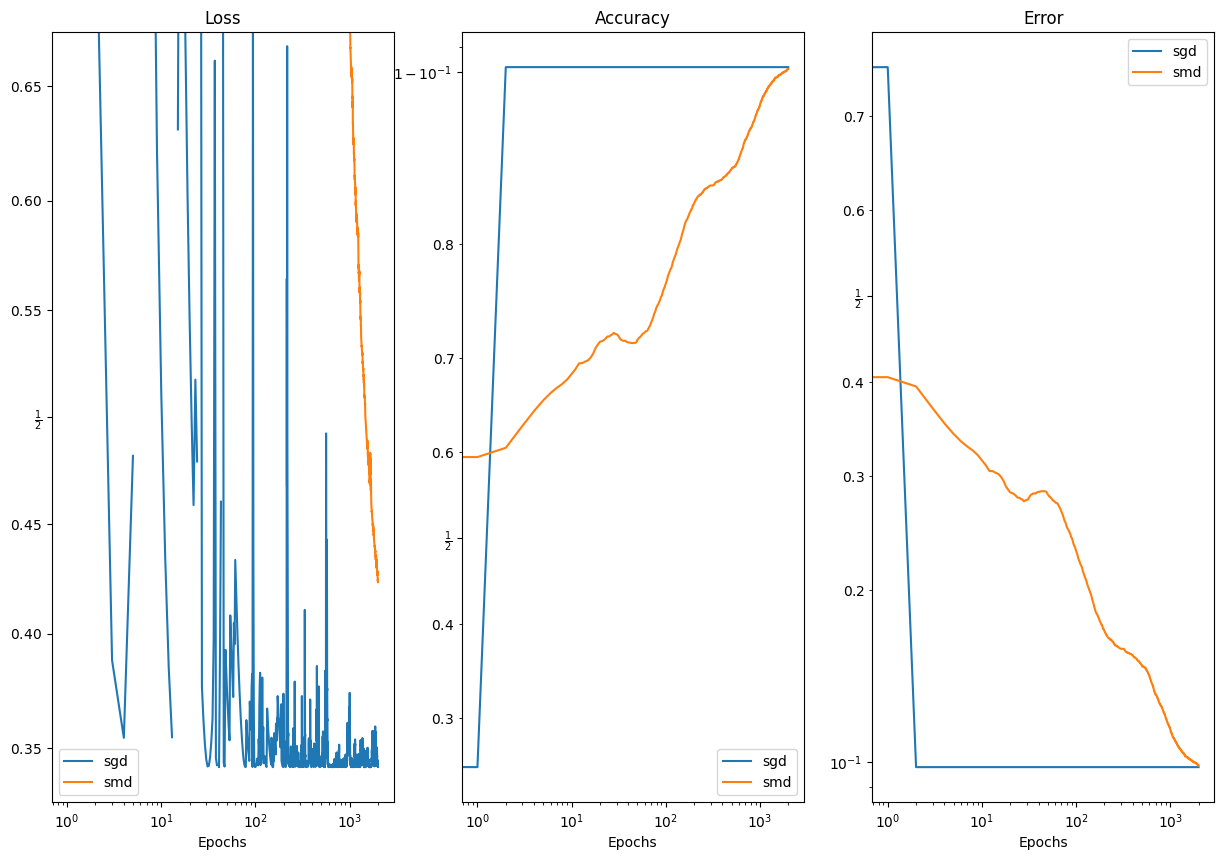

In [43]:
# Log scale
ax[0].set_xscale('log')
ax[0].set_yscale('logit')
ax[1].set_xscale('log')
ax[1].set_yscale('logit')
ax[2].set_xscale('log')
ax[2].set_yscale('logit')

# legend
ax[0].legend()
ax[1].legend()
ax[2].legend()
ax[0].set_title('Loss')
ax[1].set_title('Accuracy')
ax[2].set_title('Error')
ax[0].set_xlabel('Epochs')
ax[1].set_xlabel('Epochs')
ax[2].set_xlabel('Epochs')


#plt.savefig('LossAccuraciesErrors.png')
fig

In [37]:
import seaborn as sns

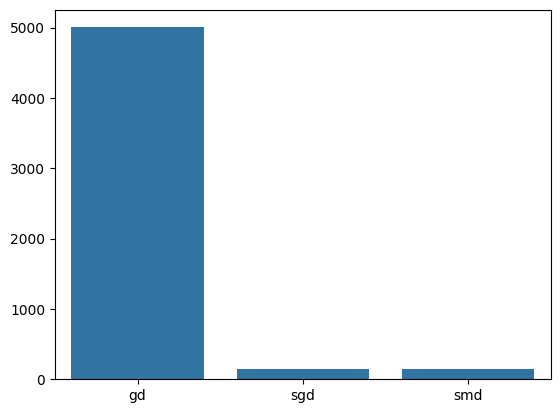

In [38]:
plt.clf()
keys = list(time_dict.keys())
sns.barplot(x=keys, y=[time_dict[k]*20 for k in keys])
plt.savefig('execution_time.png')
plt.show()